In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
experts=nn.ModuleList([
    nn.Linear(4,8),
    nn.Linear(4,8),
    nn.Linear(4,8),
    nn.Linear(4,8),
])

In [ ]:
torch.load(experts.state_dict(),map_location='cpu')

AttributeError: 'collections.OrderedDict' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

In [16]:
router = nn.Linear(4,4)

In [56]:
import torch
from soft_moe_pytorch import SoftMoE

# sequence length or number of slots need not be specified

moe = SoftMoE(
    dim = 512,         # model dimensions
    num_experts = 4,   # number of experts
    num_slots=2
)

x = torch.randn(3, 1023, 512)

out = moe(x) + x # (1, 1023, 512)

In [57]:
out

tensor([[[-0.9663,  0.0497,  1.1916,  ..., -0.5923, -0.8868,  0.9819],
         [ 0.6256,  2.1203,  0.4602,  ...,  1.7533, -1.0952,  1.6947],
         [ 1.6321, -0.7464,  0.3624,  ...,  0.9660,  0.1386, -0.1409],
         ...,
         [ 0.8337, -0.4449,  0.4215,  ...,  0.6435,  0.0072, -0.2066],
         [-0.9057,  1.1523,  0.6554,  ..., -1.2107,  0.0201,  0.0317],
         [ 0.3108,  0.5757,  0.4073,  ..., -0.3106, -0.3347, -1.2551]],

        [[ 0.4000,  0.4616, -0.5011,  ...,  1.5084, -0.6855, -0.2586],
         [-0.3314,  0.2662, -1.0329,  ..., -1.2858, -0.4509,  0.9738],
         [-0.1888,  0.8991, -2.1566,  ...,  0.0584, -0.0944,  1.0026],
         ...,
         [ 1.6559,  3.0887,  0.9769,  ..., -1.3578,  1.0792, -0.5712],
         [ 0.2703, -1.4233, -1.1462,  ...,  1.9448,  0.2962,  1.4145],
         [ 1.2019,  0.3488,  0.9903,  ..., -0.9867, -0.2492, -0.3498]],

        [[-0.6232, -0.3320,  0.3172,  ...,  0.3101,  0.9198,  2.2486],
         [-1.3614,  1.3900,  0.5456,  ...,  1

In [17]:
x=torch.rand(3,3,4)

In [18]:
router_prob= router(x)

In [19]:
router_prob

tensor([[[ 0.0951,  0.2828, -0.1241, -0.1091],
         [-0.1858,  0.2263, -0.1948, -0.0479],
         [-0.1808,  0.3582, -0.4029, -0.0471]],

        [[-0.3417,  0.3016, -0.4791, -0.0723],
         [-0.1244,  0.3227, -0.3350, -0.1737],
         [-0.1172,  0.2011, -0.1581, -0.1050]],

        [[-0.0882,  0.3914, -0.2230,  0.0541],
         [ 0.1219,  0.1038,  0.0778, -0.0690],
         [-0.1803,  0.1575, -0.2333, -0.1731]]], grad_fn=<ViewBackward0>)

In [42]:
(router_prob.topk(2,-1).indices==1)

tensor([[[ True, False],
         [ True, False],
         [ True, False]],

        [[ True, False],
         [ True, False],
         [ True, False]],

        [[ True, False],
         [False,  True],
         [ True, False]]])

In [29]:
(router_prob.topk(2,-1).indices==0).any(-1)

tensor([[ True, False, False],
        [False,  True, False],
        [False,  True, False]])

In [47]:
x

tensor([[[0.3845, 0.8068, 0.9615, 0.0709],
         [0.1558, 0.3042, 0.0902, 0.4207],
         [0.5194, 0.5300, 0.9205, 0.8273]],

        [[0.5146, 0.1142, 0.6194, 0.9823],
         [0.0381, 0.1591, 0.8057, 0.1537],
         [0.1829, 0.2849, 0.2547, 0.1964]],

        [[0.0597, 0.8427, 0.4323, 0.5704],
         [0.7633, 0.9243, 0.4951, 0.1172],
         [0.3558, 0.0152, 0.3816, 0.2515]]])

In [ ]:
topk_experts= 

In [50]:
torch.exp(-torch.tensor(torch.inf))

tensor(0.)

In [ ]:

for i,expert in enumerate(experts):
    


In [1]:
import cv2 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [4]:
image_path = '/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/images/Image_11L.jpg'

In [3]:
img = np.array(Image.open(image_path).convert('RGB'))

In [4]:
r,g,b=img.transpose(2,0,1)

In [5]:
from scipy.signal import wiener,medfilt2d

In [6]:
def apply_gamma_correction(image, gamma=1.0):
    image_normalized = image / 255.0
    gamma_corrected = np.power(image_normalized, gamma)
    gamma_corrected = np.uint8(gamma_corrected * 255)

    return gamma_corrected

In [1]:
import sys
sys.path.append('/home/duypham/NCKH/Retinal-vessels-segmentation/')
from utils import *


In [2]:
from timm.models.maxxvit import window_partition,window_reverse

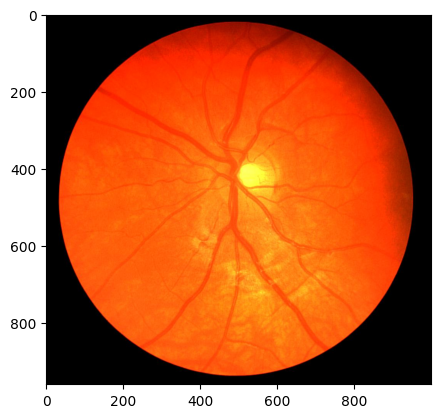

In [8]:
plt.imshow(img)

In [8]:
img=preprocessing_img(image_path)

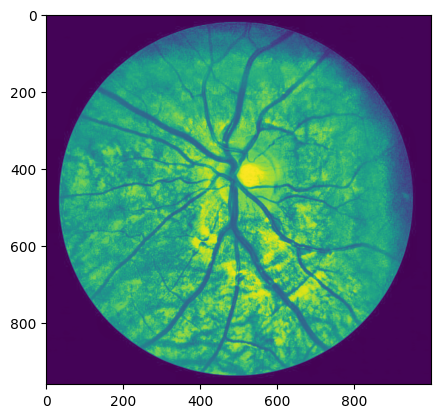

In [ ]:
plt.imshow(img)

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
tf=A.Compose([
        A.Normalize(mean=(0.5,),std=(0.5,)),
        ToTensorV2()
    ])

In [24]:
mirror_padding_v2(tf(image=img)['image']).unsqueeze(0).shape

torch.Size([1, 1, 1024, 1024])

In [44]:
window_partition(torch.rand(2,1024,768,3),[64,64]).shape

torch.Size([384, 64, 64, 3])

In [42]:
window_reverse(window_partition(torch.rand(2,1024,768,3),[64,64]),(64,64),(1024,768)).shape

torch.Size([2, 1024, 768, 3])

In [ ]:
window_reverse(window_partition(mirror_padding_v2(tf(image=img)['image']).unsqueeze(0).permute(0,2,3,1).contiguous(),[64,64]),(64,64),[1024,1024]).permute(0,3,1,2).shape

torch.Size([1, 1, 1024, 1024])

In [ ]:
]window_partition(mirror_padding_v2(tf(image=img)['image']).unsqueeze(0).permute(0,2,3,1).contiguous(),[64,64]).permute(0,3,1,2).shape

torch.Size([256, 1, 64, 64])

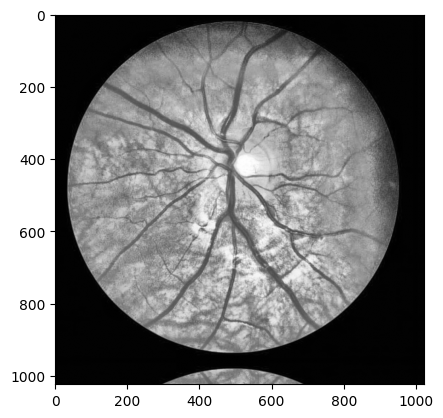

In [19]:
plt.imshow(mirror_padding_v2(tf(image=img)['image']).squeeze(),cmap='gray')

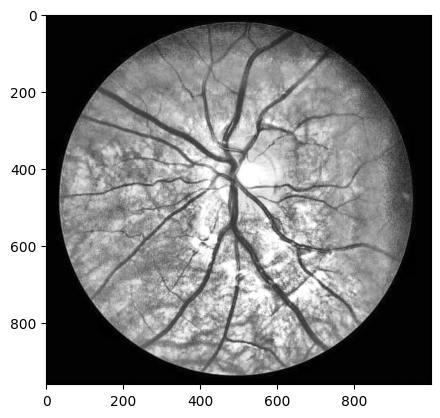

In [13]:
plt.imshow(convert_gray(gray_world(new_img)),cmap='gray')

In [14]:
wavelet_enhance(new_img,level=2, scale=1.3).shape

(960, 1000, 3)

In [15]:
img.shape

(960, 999)

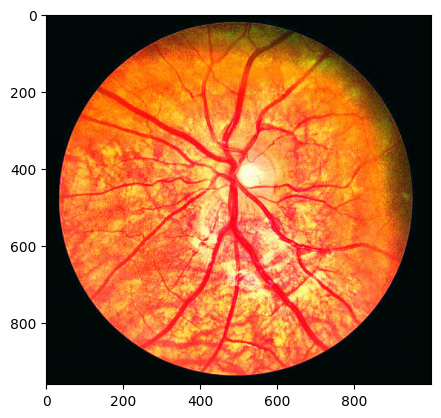

In [16]:
plt.imshow(wavelet_enhance(new_img,level=2, scale=1.3))

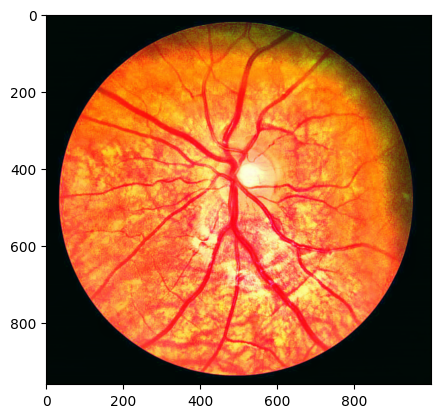

In [17]:
plt.imshow(homomorphic_filter(new_img,80))

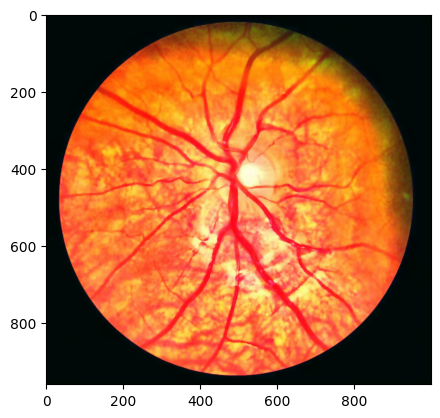

In [18]:
plt.imshow( cv2.bilateralFilter(new_img, d=9, sigmaColor=75, sigmaSpace=75))

In [19]:
unsharp_mask(new_img,amount=1.2).shape

(960, 999, 3)

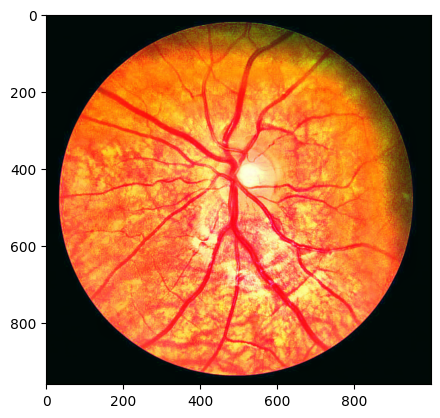

In [20]:
plt.imshow(unsharp_mask(new_img,amount=1.2))

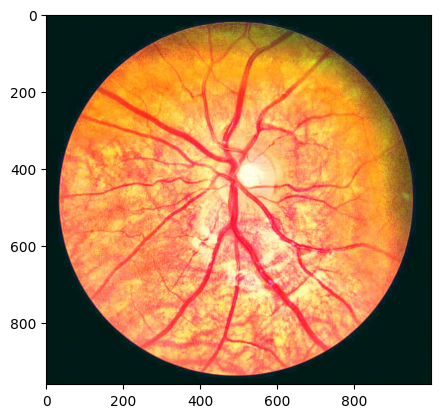

In [21]:
plt.imshow(gamma_correction(new_img,1.5))